<a href="https://colab.research.google.com/github/Teja3993/Deep-Learning-Lab-exercises/blob/main/Experiment_8_Image_Segmentation_Object_Recognition_Object_Labeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Image Segmentation (Pixel Masks)**

For segmentation, the input is an image, and the output must be an image of the exact same size, where each pixel is classified as "Object" (1) or "Background" (0). We use a simplified U-Net and Binary Crossentropy loss.

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate

# 1. Generate Synthetic Data (Squares hidden in static noise)
num_samples = 1000
img_size = 64
obj_size = 16

X_data = np.random.uniform(0, 0.5, (num_samples, img_size, img_size, 1)) # Noisy background
y_data = np.zeros((num_samples, img_size, img_size, 1))                  # Clean binary masks

for i in range(num_samples):
    x0 = np.random.randint(0, img_size - obj_size)
    y0 = np.random.randint(0, img_size - obj_size)

    # Add a solid bright square to the noisy image
    X_data[i, y0:y0+obj_size, x0:x0+obj_size, 0] = 1.0

    # Create the perfect mask
    y_data[i, y0:y0+obj_size, x0:x0+obj_size, 0] = 1.0

# 2. Build a Simplified U-Net
inputs = Input(shape=(img_size, img_size, 1))

# Encoder
c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
p1 = MaxPooling2D((2, 2))(c1)
c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)

# Decoder
u3 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c2)
concat3 = concatenate([u3, c1]) # Skip connection
c3 = Conv2D(16, (3, 3), activation='relu', padding='same')(concat3)

# Output Layer: Sigmoid predicts 0 or 1 for every single pixel
outputs = Conv2D(1, (1, 1), activation='sigmoid')(c3)

model = Model(inputs=[inputs], outputs=[outputs])

# 3. Compile: Binary Crossentropy evaluates pixel-by-pixel accuracy
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train the Model
print("--- Training Segmentation Model (Pixel Masks) ---")
model.fit(X_data, y_data, epochs=5, batch_size=32, validation_split=0.2)

# 5. Evaluate (Check how many pixels match on a sample)
pred_mask = model.predict(X_data[0:1], verbose=0)
binary_pred = (pred_mask[0] > 0.5).astype(int)

# Compare exact pixel match percentage
match_percentage = np.mean(binary_pred == y_data[0]) * 100
print(f"Pixel-Perfect Match Accuracy on Sample 1: {match_percentage:.2f}%")

--- Training Segmentation Model (Pixel Masks) ---
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 359ms/step - accuracy: 0.8745 - loss: 0.5286 - val_accuracy: 0.9375 - val_loss: 0.3824
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 296ms/step - accuracy: 0.9375 - loss: 0.2933 - val_accuracy: 0.9375 - val_loss: 0.1913
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 314ms/step - accuracy: 0.9375 - loss: 0.1378 - val_accuracy: 0.9375 - val_loss: 0.0920
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 365ms/step - accuracy: 0.9736 - loss: 0.0608 - val_accuracy: 0.9950 - val_loss: 0.0295
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 339ms/step - accuracy: 0.9961 - loss: 0.0160 - val_accuracy: 0.9964 - val_loss: 0.0107
Pixel-Perfect Match Accuracy on Sample 1: 99.54%


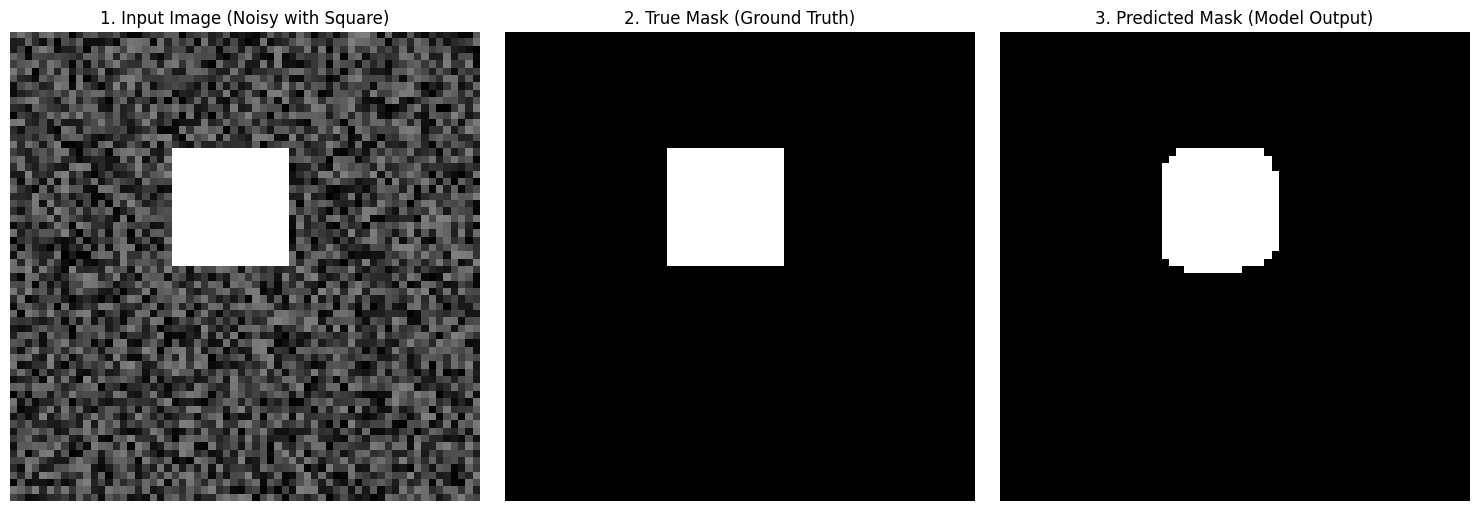

In [6]:
import matplotlib.pyplot as plt

# Extract the input image and true mask for the sample we just predicted
test_image = X_data[0]
true_mask = y_data[0]

# Set up a figure with 3 subplots side-by-side
plt.figure(figsize=(15, 5))

# 1. Plot the Input Image
plt.subplot(1, 3, 1)
plt.imshow(test_image[:, :, 0], cmap='gray')
plt.title("1. Input Image (Noisy with Square)")
plt.axis('off')

# 2. Plot the True Mask (Ground Truth)
plt.subplot(1, 3, 2)
plt.imshow(true_mask[:, :, 0], cmap='gray')
plt.title("2. True Mask (Ground Truth)")
plt.axis('off')

# 3. Plot the Predicted Mask
plt.subplot(1, 3, 3)
plt.imshow(binary_pred[:, :, 0], cmap='gray')
plt.title("3. Predicted Mask (Model Output)")
plt.axis('off')

# Display the plot
plt.tight_layout()
plt.show()

**2. Object Recognition (Detection / Bounding Boxes)**

For detection, the model must output four numbers: [x_min, y_min, x_max, y_max]. Because we are predicting continuous coordinates rather than a category, this is a Regression problem. We use Mean Squared Error (MSE) as the loss function.

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Generate Synthetic Data (White squares on black backgrounds)
num_samples = 2000
img_size = 64
obj_size = 16

X_data = np.zeros((num_samples, img_size, img_size, 1))
y_data = np.zeros((num_samples, 4)) # [x_min, y_min, x_max, y_max]

for i in range(num_samples):
    x0 = np.random.randint(0, img_size - obj_size)
    y0 = np.random.randint(0, img_size - obj_size)

    # Draw the white square
    X_data[i, y0:y0+obj_size, x0:x0+obj_size, 0] = 1.0

    # Target coordinates (Normalized between 0 and 1 for stable training)
    y_data[i] = [x0 / img_size, y0 / img_size, (x0+obj_size) / img_size, (y0+obj_size) / img_size]

# 2. Build the Model
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(4, activation='linear') # Linear activation because we are predicting coordinates
])

# 3. Compile: We use MSE because this is a regression task
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 4. Train the Model
print("--- Training Recognition Model (Bounding Boxes) ---")
model.fit(X_data, y_data, epochs=5, batch_size=32, validation_split=0.2)

# 5. Evaluate (Test on a new generated sample)
test_img = np.zeros((1, img_size, img_size, 1))
test_img[0, 10:26, 30:46, 0] = 1.0 # Square at y=10, x=30

pred = model.predict(test_img, verbose=0)
pred_coords = (pred[0] * img_size).astype(int)
print(f"True Box: [30, 10, 46, 26]")
print(f"Predicted Box: {pred_coords}")

--- Training Recognition Model (Bounding Boxes) ---
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - loss: 0.0194 - mae: 0.0791 - val_loss: 9.9600e-04 - val_mae: 0.0233
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 5.2264e-04 - mae: 0.0169 - val_loss: 3.7731e-04 - val_mae: 0.0151
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 2.1974e-04 - mae: 0.0111 - val_loss: 1.6331e-04 - val_mae: 0.0099
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 1.2490e-04 - mae: 0.0084 - val_loss: 1.4237e-04 - val_mae: 0.0092
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 9.1169e-05 - mae: 0.0072 - val_loss: 9.0184e-05 - val_mae: 0.0072
True Box: [30, 10, 46, 26]
Predicted Box: [29 10 44 26]


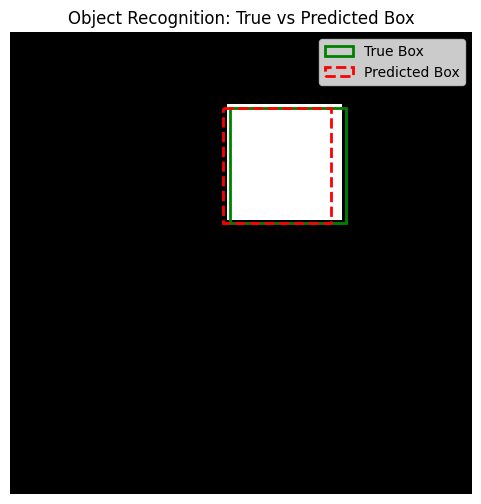

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Setup the figure and axes
fig, ax = plt.subplots(1, figsize=(6, 6))

# 2. Display the test image (using cmap='gray' for black and white)
ax.imshow(test_img[0, :, :, 0], cmap='gray')

# 3. Draw the True Bounding Box (Green)
# The true box from your test case is [30, 10, 46, 26] -> [x_min, y_min, x_max, y_max]
# Rectangle takes (x_min, y_min), width, height
true_x, true_y = 30, 10
true_width, true_height = 46 - 30, 26 - 10

true_rect = patches.Rectangle(
    (true_x, true_y), true_width, true_height,
    linewidth=2, edgecolor='green', facecolor='none', label='True Box'
)
ax.add_patch(true_rect)

# 4. Draw the Predicted Bounding Box (Red, Dashed)
# Extract the predicted coordinates
pred_x_min, pred_y_min, pred_x_max, pred_y_max = pred_coords
pred_width = pred_x_max - pred_x_min
pred_height = pred_y_max - pred_y_min

pred_rect = patches.Rectangle(
    (pred_x_min, pred_y_min), pred_width, pred_height,
    linewidth=2, edgecolor='red', facecolor='none', linestyle='--', label='Predicted Box'
)
ax.add_patch(pred_rect)

# 5. Add titles and show the plot
ax.set_title("Object Recognition: True vs Predicted Box")
ax.legend()
plt.axis('off') # Hide the axis numbers
plt.show()

**3. Object Labeling (Image Classification)**

The goal is to predict a single class label for the entire image. We use a standard CNN and Categorical Crossentropy loss.

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np

# 1. Load Data (MNIST Digits)
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess: Normalize and reshape
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# 2. Build the Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax') # 10 classes (digits 0-9)
])

# 3. Compile: We use sparse_categorical_crossentropy for integer labels
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Train the Model
print("--- Training Labeling Model (Classification) ---")
model.fit(X_train, y_train, epochs=2, batch_size=64, validation_split=0.1)

# 5. Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Labeling Accuracy: {acc * 100:.2f}%")

--- Training Labeling Model (Classification) ---
Epoch 1/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.9358 - loss: 0.2192 - val_accuracy: 0.9805 - val_loss: 0.0715
Epoch 2/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.9793 - loss: 0.0693 - val_accuracy: 0.9837 - val_loss: 0.0551
Labeling Accuracy: 98.27%


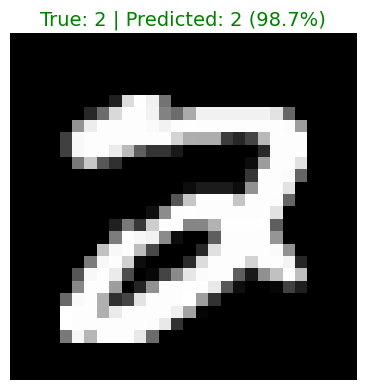

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Pick a random image from the test set
random_index = np.random.randint(0, len(X_test))
test_image = X_test[random_index]
true_label = y_test[random_index]

# 2. Make a prediction
# model.predict expects a batch of images, so we add a temporary batch dimension: (1, 28, 28, 1)
prediction = model.predict(test_image[np.newaxis, ...], verbose=0)

# 3. Get the predicted digit (the index with the highest probability)
predicted_label = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

# 4. Plot the result
plt.figure(figsize=(4, 4))
plt.imshow(test_image[:, :, 0], cmap='gray') # Plot in grayscale

# Color the title green if the AI got it right, red if it got it wrong
text_color = 'green' if predicted_label == true_label else 'red'
plt.title(f"True: {true_label} | Predicted: {predicted_label} ({confidence:.1f}%)", color=text_color, fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()